In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.colors as colors
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [2]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

In [3]:
t2m_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t2m_19['time'].values])
t2m_19 = t2m_19.assign_coords(time=shifted_time_19)
t2m_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TREFHT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t2m_19_c['time'].values])
t2m_19_c = t2m_19_c.assign_coords(time=shifted_time_19_c)
t2m_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TREFHT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t2m_22['time'].values])
t2m_22 = t2m_22.assign_coords(time=shifted_time_22)
t2m_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TREFHT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t2m_24['time'].values])
t2m_24 = t2m_24.assign_coords(time=shifted_time_24)
t2m_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t2m_1825_17tg['time'].values])
t2m_1825_17tg = t2m_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t2m_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t2m_1825['time'].values])
t2m_1825 = t2m_1825.assign_coords(time=shifted_time_1825)
t2m_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TREFHT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t2m_1tg['time'].values])
t2m_1tg = t2m_1tg.assign_coords(time=shifted_time_1tg)
t2m_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TREFHT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t2m_1pr['time'].values])
t2m_1pr = t2m_1pr.assign_coords(time=shifted_time_1pr)
t2m_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TREFHT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t2m_60tg['time'].values])
t2m_60tg = t2m_60tg.assign_coords(time=shifted_time_60tg)

t2m_rest = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_restartdir/NHIST_tropstratchem_f09_tn14_20251110_moved2iceland/TREFHT_h0_1990-1992.nc")
shifted_time_rest = np.array([shift_one_month_back(t) for t in t2m_rest['time'].values])
t2m_rest = t2m_rest.assign_coords(time=shifted_time_rest)

In [4]:
ocnmask_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/OCNFRAC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in ocnmask_19['time'].values])
ocnmask_19 = ocnmask_19.assign_coords(time=shifted_time_19)
ocnmask_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/OCNFRAC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in ocnmask_19_c['time'].values])
ocnmask_19_c = ocnmask_19_c.assign_coords(time=shifted_time_19_c)
ocnmask_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in ocnmask_22['time'].values])
ocnmask_22 = ocnmask_22.assign_coords(time=shifted_time_22)
ocnmask_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in ocnmask_24['time'].values])
ocnmask_24 = ocnmask_24.assign_coords(time=shifted_time_24)
ocnmask_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in ocnmask_1825_17tg['time'].values])
ocnmask_1825_17tg = ocnmask_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
ocnmask_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in ocnmask_1825['time'].values])
ocnmask_1825 = ocnmask_1825.assign_coords(time=shifted_time_1825)
ocnmask_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in ocnmask_1tg['time'].values])
ocnmask_1tg = ocnmask_1tg.assign_coords(time=shifted_time_1tg)
ocnmask_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/OCNFRAC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in ocnmask_1pr['time'].values])
ocnmask_1pr = ocnmask_1pr.assign_coords(time=shifted_time_1pr)
ocnmask_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/OCNFRAC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in ocnmask_60tg['time'].values])
ocnmask_60tg = ocnmask_60tg.assign_coords(time=shifted_time_60tg)

In [5]:
landmask_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/LANDFRAC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in landmask_19['time'].values])
landmask_19 = landmask_19.assign_coords(time=shifted_time_19)
landmask_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/LANDFRAC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in landmask_19_c['time'].values])
landmask_19_c = landmask_19_c.assign_coords(time=shifted_time_19_c)
landmask_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in landmask_22['time'].values])
landmask_22 = landmask_22.assign_coords(time=shifted_time_22)
landmask_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in landmask_24['time'].values])
landmask_24 = landmask_24.assign_coords(time=shifted_time_24)
landmask_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in landmask_1825_17tg['time'].values])
landmask_1825_17tg = landmask_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
landmask_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in landmask_1825['time'].values])
landmask_1825 = landmask_1825.assign_coords(time=shifted_time_1825)
landmask_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in landmask_1tg['time'].values])
landmask_1tg = landmask_1tg.assign_coords(time=shifted_time_1tg)
landmask_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/LANDFRAC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in landmask_1pr['time'].values])
landmask_1pr = landmask_1pr.assign_coords(time=shifted_time_1pr)
landmask_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/LANDFRAC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in landmask_60tg['time'].values])
landmask_60tg = landmask_60tg.assign_coords(time=shifted_time_60tg)

In [6]:
lat = t2m_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat))
lat = t2m_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = t2m_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = t2m_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = t2m_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = t2m_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = t2m_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = t2m_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = t2m_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [7]:
exp_order = [
    "10Tg, 19km (all)",
    "10Tg, 19km",
    "10Tg, 22km",
    "17Tg, 24km",
    "10Tg, 18-25km",
    "17Tg, 18-25km",
    "10Tg, 19km (1% SO$_4$)",
    #"1Tg, 19km",
    #"60Tg, 19km"
]

colors = {
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    #"1Tg, 19km": "orange",
    #"60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km (all)": t2m_19["TREFHT"],
    "10Tg, 19km": t2m_19_c["TREFHT"],
    "10Tg, 22km": t2m_22["TREFHT"],
    "17Tg, 24km": t2m_24["TREFHT"],
    "10Tg, 18-25km": t2m_1825["TREFHT"],
    "17Tg, 18-25km": t2m_1825_17tg["TREFHT"],
    "10Tg, 19km (1% SO$_4$)": t2m_1pr["TREFHT"],
    #"1Tg, 19km": t2m_1tg["TREFHT"],
    #"60Tg, 19km": t2m_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km (all)": landmask_19["LANDFRAC"],
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "10Tg, 22km": landmask_22["LANDFRAC"],
    "17Tg, 24km": landmask_24["LANDFRAC"],
    "10Tg, 18-25km": landmask_1825["LANDFRAC"],
    "17Tg, 18-25km": landmask_1825_17tg["LANDFRAC"],
    "10Tg, 19km (1% SO$_4$)": landmask_1pr["LANDFRAC"],
    #"1Tg, 19km": landmask_1tg["LANDFRAC"],
    #"60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km (all)": weighted_lat_19,
    "10Tg, 19km": weighted_lat_19_c,
    "10Tg, 22km": weighted_lat_22,
    "17Tg, 24km": weighted_lat_24,
    "10Tg, 18-25km": weighted_lat_1825,
    "17Tg, 18-25km": weighted_lat_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": weighted_lat_1pr,
    #"1Tg, 19km": weighted_lat_1tg,
    #"60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

base_land = land_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))
base_ocean = ocean_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/1272368961.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


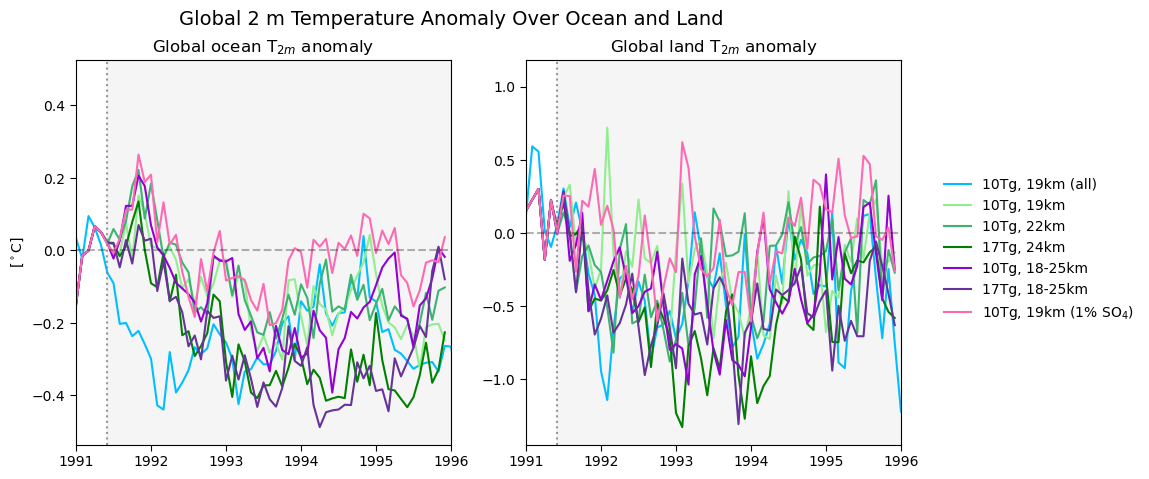

In [8]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in exp_order:
    c = colors[name]

    ax[0].plot(to_float(ocean_anom_dict[name]), ocean_anom_dict[name], color=c, label=name)
    ax[1].plot(to_float(land_anom_dict[name]), land_anom_dict[name], color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean T$_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land T$_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.95)
fig.suptitle("Global 2 m Temperature Anomaly Over Ocean and Land", fontsize=14)

plt.show()

In [9]:
exp_order = [
    "10Tg, 19km (all)",
    "10Tg, 19km",
    "10Tg, 22km",
    "17Tg, 24km",
    "10Tg, 18-25km",
    "17Tg, 18-25km",
    "10Tg, 19km (1% SO$_4$)",
    "1Tg, 19km",
    "60Tg, 19km"
]

colors = {
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km (all)": t2m_19["TREFHT"],
    "10Tg, 19km": t2m_19_c["TREFHT"],
    "10Tg, 22km": t2m_22["TREFHT"],
    "17Tg, 24km": t2m_24["TREFHT"],
    "10Tg, 18-25km": t2m_1825["TREFHT"],
    "17Tg, 18-25km": t2m_1825_17tg["TREFHT"],
    "10Tg, 19km (1% SO$_4$)": t2m_1pr["TREFHT"],
    "1Tg, 19km": t2m_1tg["TREFHT"],
    "60Tg, 19km": t2m_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km (all)": landmask_19["LANDFRAC"],
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "10Tg, 22km": landmask_22["LANDFRAC"],
    "17Tg, 24km": landmask_24["LANDFRAC"],
    "10Tg, 18-25km": landmask_1825["LANDFRAC"],
    "17Tg, 18-25km": landmask_1825_17tg["LANDFRAC"],
    "10Tg, 19km (1% SO$_4$)": landmask_1pr["LANDFRAC"],
    "1Tg, 19km": landmask_1tg["LANDFRAC"],
    "60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km (all)": weighted_lat_19,
    "10Tg, 19km": weighted_lat_19_c,
    "10Tg, 22km": weighted_lat_22,
    "17Tg, 24km": weighted_lat_24,
    "10Tg, 18-25km": weighted_lat_1825,
    "17Tg, 18-25km": weighted_lat_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": weighted_lat_1pr,
    "1Tg, 19km": weighted_lat_1tg,
    "60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

base_land = land_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))
base_ocean = ocean_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

for name in exp_order:
    land_anom_dict[name] = land_anom_dict[name].sel(time=slice(None, "1995-12"))
    ocean_anom_dict[name] = ocean_anom_dict[name].sel(time=slice(None, "1995-12"))

In [10]:
rows = []

for name in exp_order:
    ocean = ocean_anom_dict[name]
    land = land_anom_dict[name]

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn).values.item()
    t_lnd = land.time.isel(time=i_lnd).values.item()

    v_ocn = float(ocean.isel(time=i_ocn).values)
    v_lnd = float(land.isel(time=i_lnd).values)

    lag_months = (t_ocn.year - t_lnd.year) * 12 + (t_ocn.month - t_lnd.month)

    rows.append({
        "Experiment": name,
        "Ocean min time": f"{t_ocn.year:04d}-{t_ocn.month:02d}",
        "Ocean min [°C]": round(v_ocn, 2),
        "Land min time": f"{t_lnd.year:04d}-{t_lnd.month:02d}",
        "Land min [°C]": round(v_lnd, 2),
        "Ocean minus land lag [months]": lag_months
    })

minima_df = pd.DataFrame(rows)
minima_df

,Experiment,Ocean min time,Ocean min [°C],Land min time,Land min [°C],Ocean minus land lag [months]
0,"10Tg, 19km (all)",1992-03,-0.44,1992-02,-1.14,1
1,"10Tg, 19km",1995-08,-0.33,1992-12,-0.73,32
2,"10Tg, 22km",1995-07,-0.26,1992-12,-0.88,31
3,"17Tg, 24km",1995-06,-0.43,1993-02,-1.33,28
4,"10Tg, 18-25km",1994-06,-0.39,1993-03,-1.04,15
5,"17Tg, 18-25km",1994-04,-0.49,1993-11,-1.31,5
6,"10Tg, 19km (1% SO$_4$)",1993-08,-0.21,1994-01,-0.61,-5
7,"1Tg, 19km",1991-01,-0.15,1994-12,-0.26,-47
8,"60Tg, 19km",1993-11,-1.53,1993-11,-3.13,0


In [11]:
rows = []

for name in exp_order:
    ocean = ocean_anom_dict[name].sel(time=slice("1991-06", "1993-12"))
    land = land_anom_dict[name].sel(time=slice("1991-06", "1993-12"))

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn).values.item()
    t_lnd = land.time.isel(time=i_lnd).values.item()

    v_ocn = float(ocean.isel(time=i_ocn).values)
    v_lnd = float(land.isel(time=i_lnd).values)

    lag_months = (t_ocn.year - t_lnd.year) * 12 + (t_ocn.month - t_lnd.month)

    rows.append({
        "Experiment": name,
        "Ocean min time": f"{t_ocn.year:04d}-{t_ocn.month:02d}",
        "Ocean min [°C]": round(v_ocn, 2),
        "Land min time": f"{t_lnd.year:04d}-{t_lnd.month:02d}",
        "Land min [°C]": round(v_lnd, 2),
        "Ocean minus land lag [months]": lag_months
    })

minima_df_window = pd.DataFrame(rows)
minima_df_window

,Experiment,Ocean min time,Ocean min [°C],Land min time,Land min [°C],Ocean minus land lag [months]
0,"10Tg, 19km (all)",1992-03,-0.44,1992-02,-1.14,1
1,"10Tg, 19km",1993-10,-0.30,1992-12,-0.73,10
2,"10Tg, 22km",1993-09,-0.24,1992-12,-0.88,9
3,"17Tg, 24km",1993-06,-0.41,1993-02,-1.33,4
4,"10Tg, 18-25km",1993-08,-0.33,1993-03,-1.04,5
5,"17Tg, 18-25km",1993-06,-0.43,1993-11,-1.31,-5
6,"10Tg, 19km (1% SO$_4$)",1993-08,-0.21,1992-10,-0.60,10
7,"1Tg, 19km",1991-08,-0.02,1992-11,-0.22,-15
8,"60Tg, 19km",1993-11,-1.53,1993-11,-3.13,0


In [12]:
exp_order = [
    "10Tg, 19km",
    "1Tg, 19km",
    "60Tg, 19km"
]

colors = {
    "10Tg, 19km": "lightgreen",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km": t2m_19_c["TREFHT"],
    "1Tg, 19km": t2m_1tg["TREFHT"],
    "60Tg, 19km": t2m_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "1Tg, 19km": landmask_1tg["LANDFRAC"],
    "60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km": weighted_lat_19_c,
    "1Tg, 19km": weighted_lat_1tg,
    "60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/710154999.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


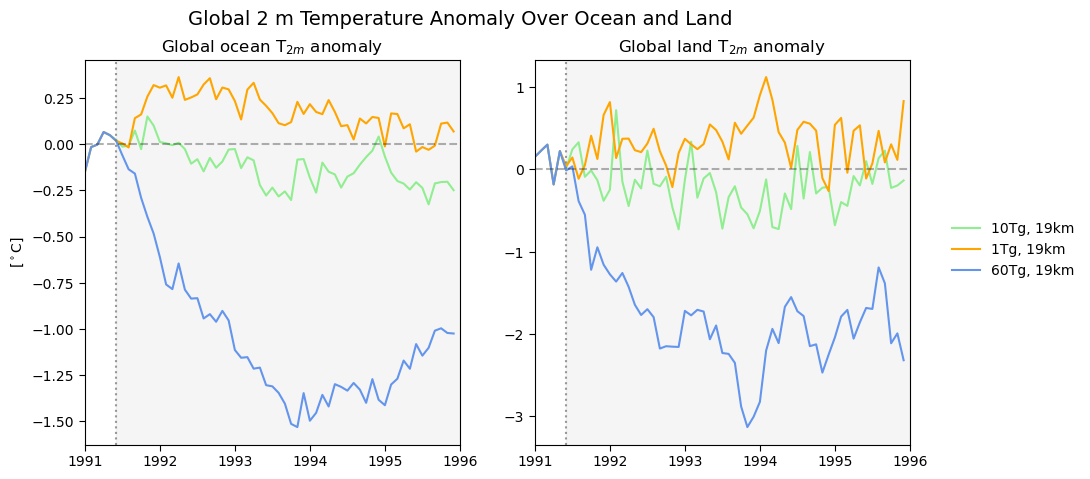

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in exp_order:
    c = colors[name]

    ax[0].plot(to_float(ocean_anom_dict[name]), ocean_anom_dict[name], color=c, label=name)
    ax[1].plot(to_float(land_anom_dict[name]), land_anom_dict[name], color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean T$_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land T$_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.95)
fig.suptitle("Global 2 m Temperature Anomaly Over Ocean and Land", fontsize=14)

plt.show()

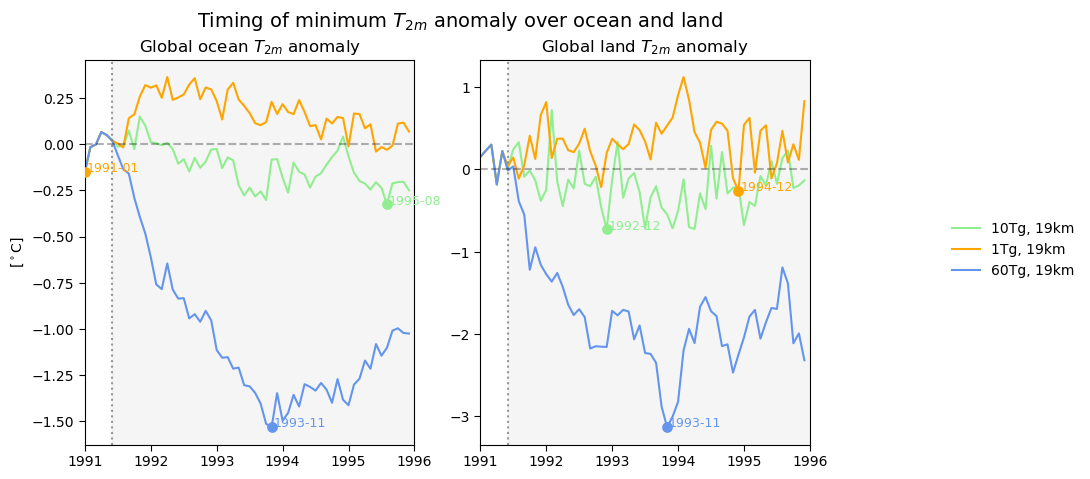

In [14]:
key_cases = ["10Tg, 19km", "1Tg, 19km", "60Tg, 19km"]
def time_to_float(t):
    t = t.values.item()
    return t.year + (t.month - 1) / 12


fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in key_cases:
    c = colors[name]

    ocean = ocean_anom_dict[name]
    land = land_anom_dict[name]

    ax[0].plot(to_float(ocean), ocean, color=c, label=name)
    ax[1].plot(to_float(land), land, color=c, label=name)

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn)
    t_lnd = land.time.isel(time=i_lnd)

    v_ocn = ocean.isel(time=i_ocn)
    v_lnd = land.isel(time=i_lnd)

    ax[0].scatter(time_to_float(t_ocn), float(v_ocn.values), color=c, s=45, zorder=6)
    ax[1].scatter(time_to_float(t_lnd), float(v_lnd.values), color=c, s=45, zorder=6)

    ax[0].text(time_to_float(t_ocn) + 0.03, float(v_ocn.values), str(t_ocn.values)[:7], color=c, fontsize=9)
    ax[1].text(time_to_float(t_lnd) + 0.03, float(v_lnd.values), str(t_lnd.values)[:7], color=c, fontsize=9)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean $T_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land $T_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.85)
fig.suptitle("Timing of minimum $T_{2m}$ anomaly over ocean and land", fontsize=14)

plt.show()

In [15]:
def global_mean(da):
    lat = da["lat"]
    weights = np.cos(np.deg2rad(lat))
    return da.weighted(weights).mean(dim=("lat", "lon"))

ts_19 = global_mean(t2m_19["TREFHT"]).sel(time=slice("1991-01", "1996-01")) - 273.15
ts_19_c = global_mean(t2m_19_c["TREFHT"]) - 273.15
ts_22 = global_mean(t2m_22["TREFHT"]) - 273.15
ts_24 = global_mean(t2m_24["TREFHT"]) - 273.15
ts_1825 = global_mean(t2m_1825["TREFHT"]) - 273.15
ts_1825_17tg = global_mean(t2m_1825_17tg["TREFHT"]) - 273.15
ts_1tg = global_mean(t2m_1tg["TREFHT"]) - 273.15
ts_1pr = global_mean(t2m_1pr["TREFHT"]) - 273.15
ts_60tg = global_mean(t2m_60tg["TREFHT"]) - 273.15

In [16]:
temp_ctrl = t2m_19["TREFHT"]-273.15
baseline = temp_ctrl.sel(time=slice("1986-01", "1990-12"))
base = global_mean(baseline)
base = base.groupby("time.month").mean("time")

def anomalies(da, base_monthly):
    return da.groupby("time.month") - base_monthly

a_19 = anomalies(ts_19, base)
a_19_c = anomalies(ts_19_c, base)
a_22 = anomalies(ts_22, base)
a_24 = anomalies(ts_24, base)
a_1825 = anomalies(ts_1825, base)
a_1825_17tg = anomalies(ts_1825_17tg, base)
a_1tg = anomalies(ts_1tg, base)
a_1pr = anomalies(ts_1pr, base)
a_60tg = anomalies(ts_60tg, base)

base_std = global_mean(baseline).groupby("time.month").std("time")

In [34]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)

t_rest = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_restartdir/NHIST_tropstratchem_f09_tn14_20251110_moved2iceland/TS_h0_1990-1992.nc")
shifted_time_rest = np.array([shift_one_month_back(t) for t in t_rest['time'].values])
t_rest = t_rest.assign_coords(time=shifted_time_rest)

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/1968435375.py:33: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Temperature [$^\circ$C]')


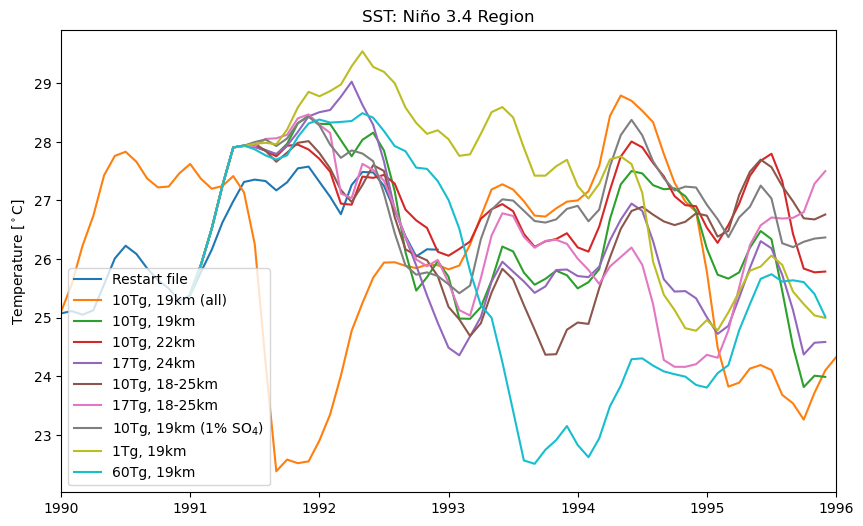

In [35]:
def time_to_float_array(time_coord):
    vals = np.asarray(time_coord.values)
    return np.array([t.year + (t.month - 1)/12 for t in vals])

def get_nino34(ds):
    nino_box = ds.TS.sel(lat=slice(-5, 5), lon=slice(190, 240)) - 273.15
    
    weights = np.cos(np.deg2rad(nino_box.lat))
    return nino_box.weighted(weights).mean(dim=['lat', 'lon'])

sst_19 = t_19.sel(time=slice("1990-01", "1996-01"))
exp_dict = {
    "Restart file": t_rest,
    "10Tg, 19km (all)": sst_19,
    "10Tg, 19km": t_19_c,
    "10Tg, 22km": t_22,
    "17Tg, 24km": t_24,
    "10Tg, 18-25km": t_1825,
    "17Tg, 18-25km": t_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": t_1pr,
    "1Tg, 19km": t_1tg,
    "60Tg, 19km": t_60tg
}

plt.figure(figsize=(10, 6))

for name, ds in exp_dict.items():
    nino_ts = get_nino34(ds)
    t_float = time_to_float_array(nino_ts.time)
    plt.plot(t_float, nino_ts.values, label=name)

plt.title('SST: Niño 3.4 Region')
plt.ylabel('Temperature [$^\circ$C]')
plt.xlim(1990, 1996)
plt.xticks([1990, 1991, 1992, 1993, 1994, 1995, 1996])
plt.legend()
plt.show()

In [36]:
sst_19_base = get_nino34(t_19.sel(time=slice("1986-01", "1990-12")))
sst_19_base = sst_19_base.groupby("time.month").mean(dim="time")

baseline_ts = (
    (t_19["TS"] - 273.15)
    .sel(time=slice("1986-01", "1990-12"))
    .groupby("time.month")
    .mean("time")
)

In [37]:
def get_roni_anom(ds, base):
    ts = ds["TS"] - 273.15

    sst_anom = ts.groupby("time.month") - base

    nino = sst_anom.sel(lat=slice(-5, 5), lon=slice(190, 240))
    w_nino = np.cos(np.deg2rad(nino.lat))
    nino_34_raw = nino.weighted(w_nino).mean(dim=["lat", "lon"])

    trop = sst_anom.sel(lat=slice(-20, 20))
    w_trop = np.cos(np.deg2rad(trop.lat))
    trop_mean_raw = trop.weighted(w_trop).mean(dim=["lat", "lon"])

    roni_raw = nino_34_raw - trop_mean_raw

    scaling_factor = nino_34_raw.std(dim="time") / roni_raw.std(dim="time")
    roni_scaled = roni_raw * scaling_factor

    return roni_scaled.rolling(time=3, center=True).mean()

<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:25: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/408191417.py:25: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Temperature [$^\circ$C]')


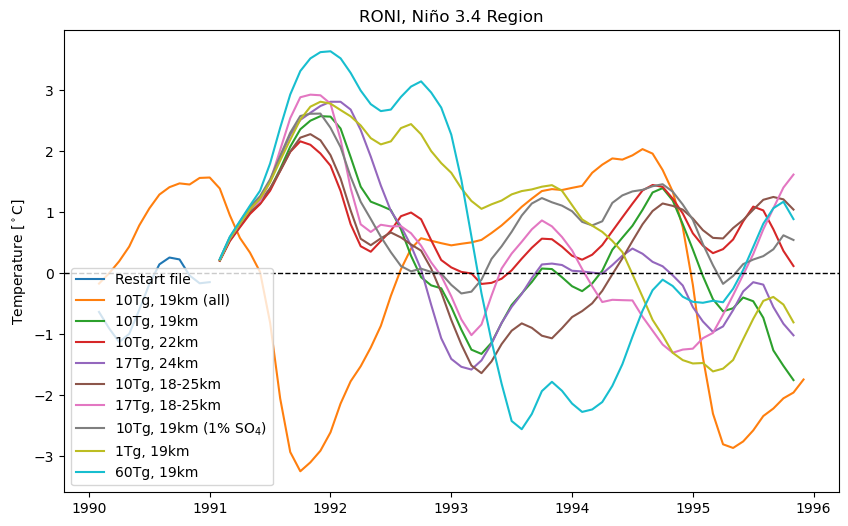

In [38]:
sst_19 = t_19.sel(time=slice("1990-01", "1996-01"))
t_rest = t_rest.sel(time=slice("1990-01", "1991-02"))
exp_dict = {
    "Restart file": t_rest,
    "10Tg, 19km (all)": sst_19,
    "10Tg, 19km": t_19_c,
    "10Tg, 22km": t_22,
    "17Tg, 24km": t_24,
    "10Tg, 18-25km": t_1825,
    "17Tg, 18-25km": t_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": t_1pr,
    "1Tg, 19km": t_1tg,
    "60Tg, 19km": t_60tg
}

plt.figure(figsize=(10, 6))

for name, ds in exp_dict.items():
    roni_ts = get_roni_anom(ds, baseline_ts)
    t_float = np.array([t.year + (t.month - 1)/12 for t in roni_ts.time.values])
    plt.plot(t_float, roni_ts.values, label=name)

plt.axhline(0, color='black', lw=1, ls='--')
plt.title('RONI, Niño 3.4 Region')
plt.ylabel('Temperature [$^\circ$C]')
plt.legend()
plt.show()

In [39]:
def global_t2m_mean(ds, weights):
    return ds["TREFHT"].weighted(weights).mean(dim=["lat", "lon"]) - 273.15

t2m_ctrl = global_t2m_mean(t2m_19, weighted_lat_19)

baseline = t2m_ctrl.sel(time=slice("1986-01", "1990-12"))
base_monthly = baseline.groupby("time.month").mean("time")

def global_t2m_anom(ds, weights, base_monthly, period=("1990-01", "1996-01")):
    t2m = global_t2m_mean(ds, weights)
    anom = t2m.groupby("time.month") - base_monthly
    return anom.sel(time=slice(period[0], period[1]))

In [40]:
lat = t2m_rest["lat"]
weighted_lat_rest = np.cos(np.deg2rad(lat))
t2m_anom_dict = {
    "Restart file": global_t2m_anom(t2m_rest, weighted_lat_rest, base_monthly, period=("1990-01", "1992-12")),
    "10Tg, 19km (all)": global_t2m_anom(t2m_19, weighted_lat_19, base_monthly),
    "10Tg, 19km": global_t2m_anom(t2m_19_c, weighted_lat_19_c, base_monthly),
    "10Tg, 22km": global_t2m_anom(t2m_22, weighted_lat_22, base_monthly),
    "17Tg, 24km": global_t2m_anom(t2m_24, weighted_lat_24, base_monthly),
    "10Tg, 18-25km": global_t2m_anom(t2m_1825, weighted_lat_1825, base_monthly),
    "17Tg, 18-25km": global_t2m_anom(t2m_1825_17tg, weighted_lat_1825_17tg, base_monthly),
    "10Tg, 19km (1% SO$_4$)": global_t2m_anom(t2m_1pr, weighted_lat_1pr, base_monthly),
    "1Tg, 19km": global_t2m_anom(t2m_1tg, weighted_lat_1tg, base_monthly),
    "60Tg, 19km": global_t2m_anom(t2m_60tg, weighted_lat_60tg, base_monthly),
}

<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/2451110420.py:43: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


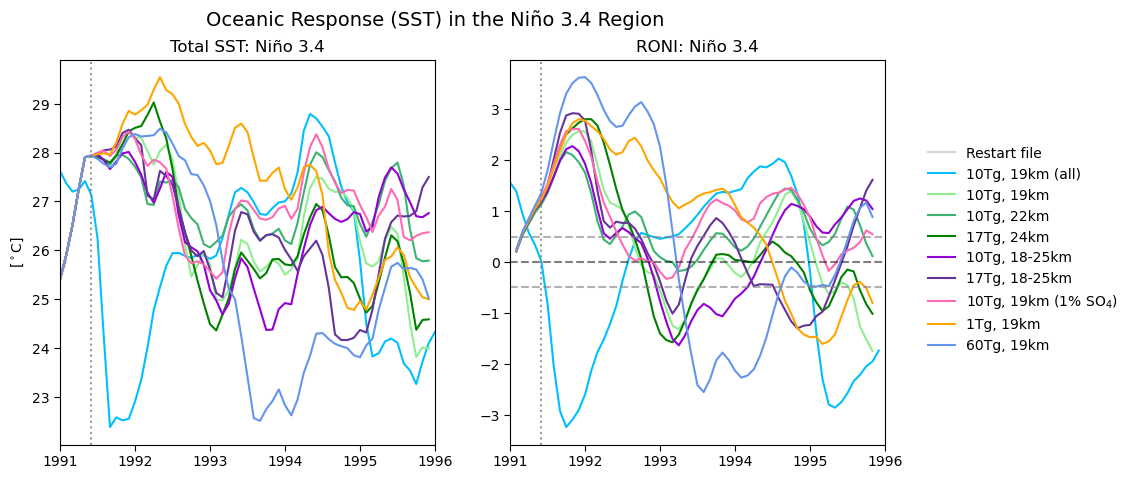

In [41]:
colors = {
    "Restart file": "lightgrey",
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for name, ds in exp_dict.items():
    total_nino = get_nino34(ds)
    anom_nino = get_roni_anom(ds, baseline_ts)
    
    c = colors.get(name, "black")
    
    ax[0].plot(to_float(total_nino), total_nino, color=c, label=name)
    
    ax[1].plot(to_float(anom_nino), anom_nino, color=c, label=name)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    if i == 1:
        a.axhline(0, color="black", ls="--", alpha=0.5)

    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction='out', length=4)

ax[0].set_title("Total SST: Niño 3.4", fontsize=12)
ax[1].set_title("RONI: Niño 3.4", fontsize=12)
ax[1].axhline(-0.5, color="gray", ls="--", alpha=0.6)
ax[1].axhline(0.5, color="gray", ls="--", alpha=0.6)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.subplots_adjust(right=0.95)

fig.suptitle("Oceanic Response (SST) in the Niño 3.4 Region", fontsize=14)
plt.show()

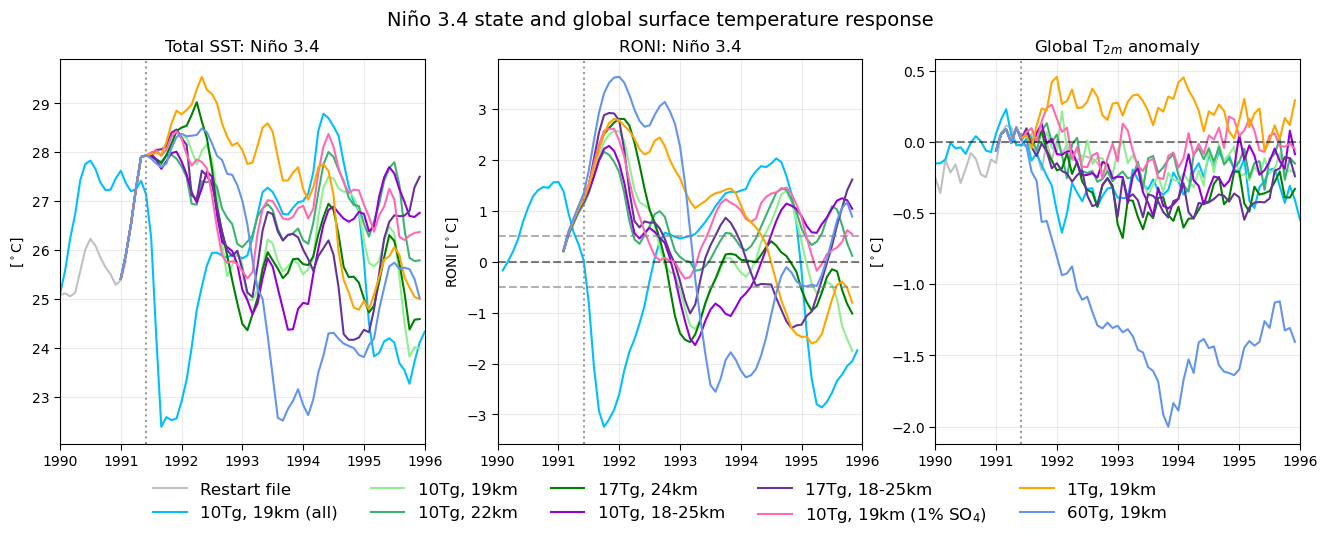

In [46]:
colors = {
    "Restart file": "silver",
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for name, ds in exp_dict.items():
    c = colors.get(name, "black")

    total_nino = get_nino34(ds)
    ax[0].plot(to_float(total_nino), total_nino, color=c, label=name)

    if name != "Restart file":
        anom_nino = get_roni_anom(ds, baseline_ts)
        ax[1].plot(to_float(anom_nino), anom_nino, color=c, label=name)

    if name in t2m_anom_dict:
        t2m_anom = t2m_anom_dict[name]
        ax[2].plot(to_float(t2m_anom), t2m_anom, color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.set_xlim(1990, 1996)
    a.set_xticks(np.arange(1990, 1997, 1))
    a.set_xticklabels([str(y) for y in range(1990, 1997)])
    a.tick_params(direction="out", length=4)
    a.grid(True, alpha=0.25)

ax[1].axhline(0, color="black", ls="--", alpha=0.5)
ax[1].axhline(-0.5, color="gray", ls="--", alpha=0.6)
ax[1].axhline(0.5, color="gray", ls="--", alpha=0.6)

ax[2].axhline(0, color="black", ls="--", alpha=0.5)

ax[0].set_title("Total SST: Niño 3.4", fontsize=12)
ax[1].set_title("RONI: Niño 3.4", fontsize=12)
ax[2].set_title("Global T$_{2m}$ anomaly", fontsize=12)

ax[0].set_ylabel("[$^\\circ$C]")
ax[1].set_ylabel("RONI [$^\\circ$C]")
ax[2].set_ylabel("[$^\\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,            
    frameon=False,
    fontsize=12
)

fig.suptitle("Niño 3.4 state and global surface temperature response", fontsize=14)

plt.show()

In [26]:
def ocean_mask(ds_temp, ds_ocn):
    ocnmaskd_temp = ds_temp["TS"].where(ds_ocn["OCNFRAC"] > 0)
    return ocnmaskd_temp

ocn_temp_19 = ocean_mask(sst_19, ocnmask_19)
ocn_temp_19_c = ocean_mask(t_19_c, ocnmask_19_c)
ocn_temp_22 = ocean_mask(t_22, ocnmask_22)
ocn_temp_24 = ocean_mask(t_24, ocnmask_24)
ocn_temp_1825 = ocean_mask(t_1825, ocnmask_1825)
ocn_temp_1825_17tg = ocean_mask(t_1825_17tg, ocnmask_1825_17tg)
ocn_temp_1pr = ocean_mask(t_1pr, ocnmask_1pr)
ocn_temp_1tg = ocean_mask(t_1tg, ocnmask_1tg)
ocn_temp_60tg = ocean_mask(t_60tg, ocnmask_60tg)

In [27]:
ocean_long = ocean_mask(t_19, ocnmask_19)
base_ocn = ocean_long.sel(time=slice("1986-01", "1990-12"))
base_ocn = base_ocn.groupby("time.month").mean(dim="time")

In [28]:
sst_anom_maps_19 = ocn_temp_19.groupby("time.month") - base_ocn
sst_anom_maps_19_c = ocn_temp_19_c.groupby("time.month") - base_ocn
sst_anom_maps_22 = ocn_temp_22.groupby("time.month") - base_ocn
sst_anom_maps_24 = ocn_temp_24.groupby("time.month") - base_ocn
sst_anom_maps_1825 = ocn_temp_1825.groupby("time.month") - base_ocn
sst_anom_maps_1825_17tg = ocn_temp_1825_17tg.groupby("time.month") - base_ocn
sst_anom_maps_1pr = ocn_temp_1pr.groupby("time.month") - base_ocn
sst_anom_maps_1tg = ocn_temp_1tg.groupby("time.month") - base_ocn
sst_anom_maps_60tg = ocn_temp_60tg.groupby("time.month") - base_ocn

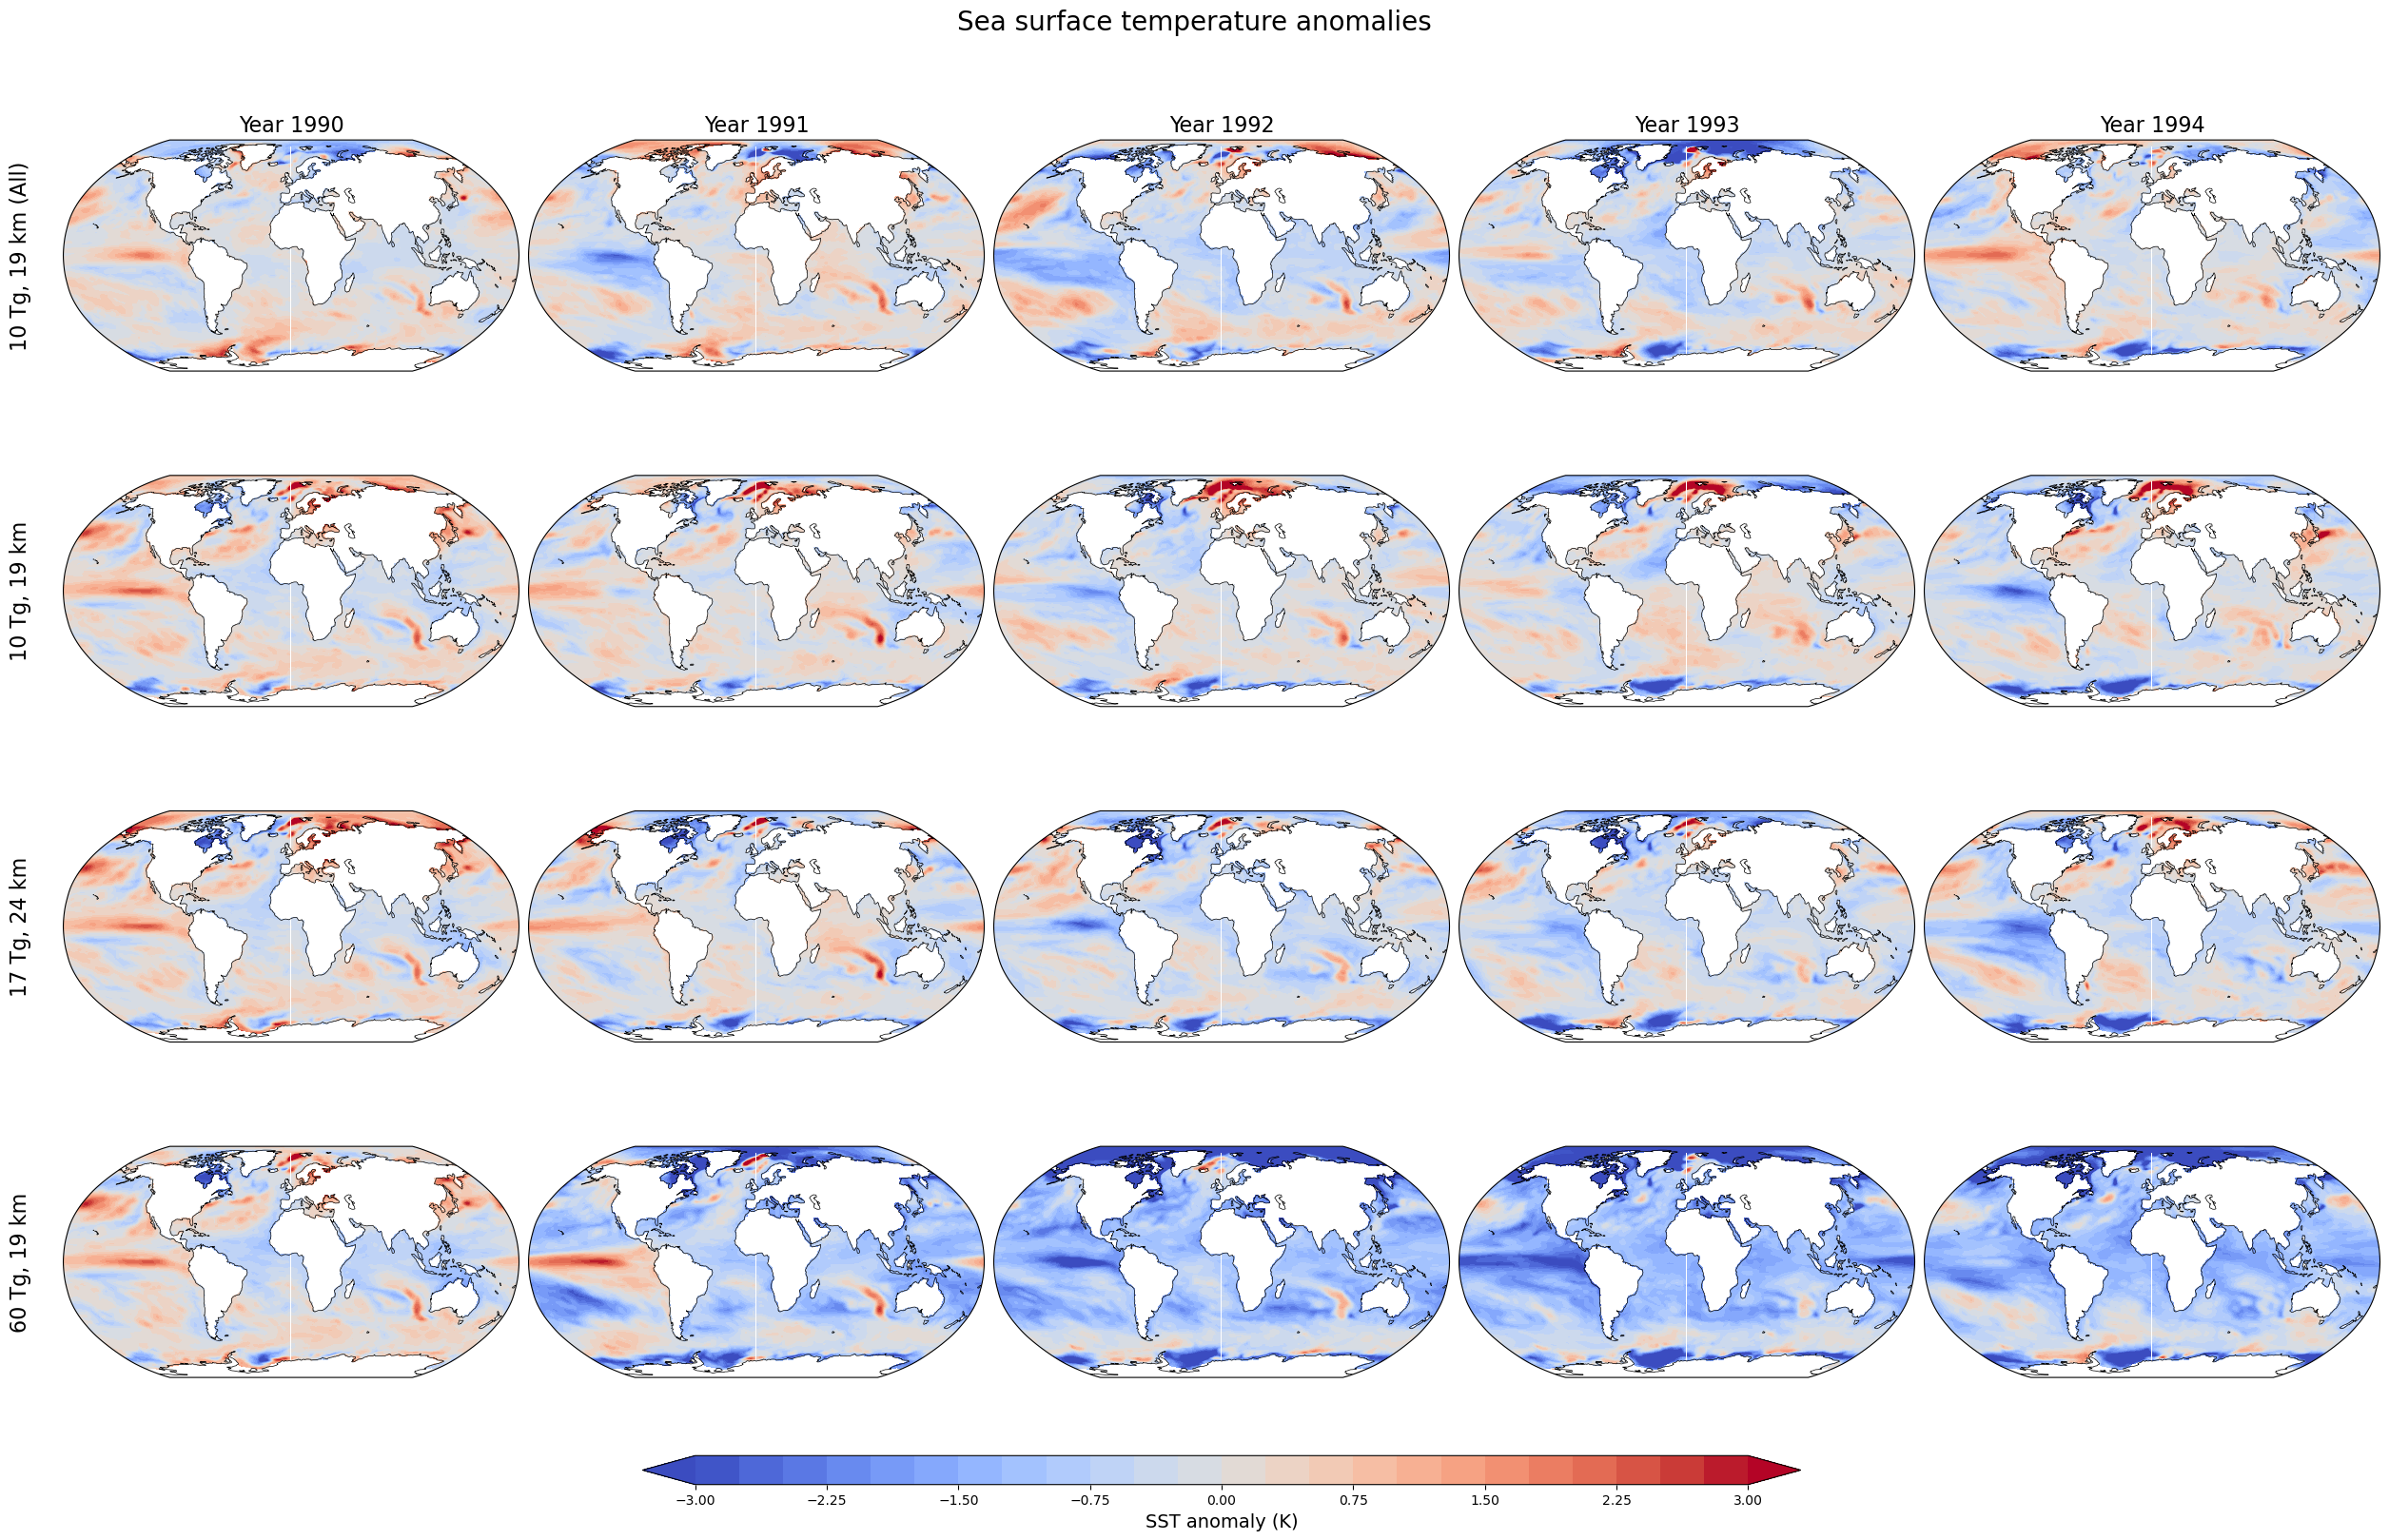

In [29]:
experiments = [
    ("10 Tg, 19 km (All)", sst_anom_maps_19.resample(time="YS").mean()),
    ("10 Tg, 19 km", sst_anom_maps_19_c.resample(time="YS").mean()),
    ("17 Tg, 24 km", sst_anom_maps_24.resample(time="YS").mean()),
    ("60 Tg, 19 km", sst_anom_maps_60tg.resample(time="YS").mean())
]

n_rows = len(experiments)
n_cols = 5 
levels = np.linspace(-3, 3, 25) 

fig, axs = plt.subplots(n_rows, n_cols, figsize=(25, 4 * n_rows), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        constrained_layout=True)

if n_rows == 1:
    axs = axs.reshape(1, -1)

for row_idx, (exp_name, exp_data) in enumerate(experiments):
    
    for col_idx in range(n_cols):
        ax = axs[row_idx, col_idx]
        t = exp_data["time"][col_idx]
        data_for_year = exp_data.sel(time=t)
        year_str = str(t.dt.year.values)

        ax.coastlines(resolution='110m', linewidth=0.5)
        ax.set_global()

        cf = ax.contourf(
            exp_data.lon, 
            exp_data.lat, 
            data_for_year, 
            transform=ccrs.PlateCarree(),
            levels=levels,
            cmap='coolwarm',
            extend='both' 
        )

        if row_idx == 0:
            ax.set_title(f"Year {year_str}", fontsize=16)
        
        if col_idx == 0:
            ax.text(-0.07, 0.5, exp_name, transform=ax.transAxes, 
                    va='center', ha='right', fontsize=16, rotation=90)

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', pad=0.05, shrink=0.5, aspect=40)
cbar.set_label('SST anomaly (K)', fontsize=14)

plt.suptitle('Sea surface temperature anomalies', fontsize=20)
plt.show()

In [30]:
ocean_long = ocean_mask(t_19, ocnmask_19)
weights = weighted_lat_19.broadcast_like(ocean_long)
baseline = ocean_long.sel(time=slice("1986-01", "1990-12"))
baseline_ts = baseline.weighted(weights).mean(dim=["lat", "lon"])
baseline_clim = baseline_ts.groupby("time.month").mean("time")
baseline_climatology = baseline_ts.groupby("time.month").mean()
baseline_anomalies = baseline_ts.groupby("time.month") - baseline_climatology

baseline_sst_std = baseline_anomalies.std()

In [31]:
def get_global_sst_anom(ds, base_clim, ocn_masks, weighted):
    sst = ocean_mask(ds["TS"], ocn_masks)
    weights = weighted.broadcast_like(sst)
    sst_ts = sst.weighted(weights).mean(dim=["lat", "lon"])
    sst_anom = sst_ts.groupby("time.month") - base_clim
    return sst_anom

<>:129: SyntaxWarning: invalid escape sequence '\c'
<>:129: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3559574/2571803292.py:129: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


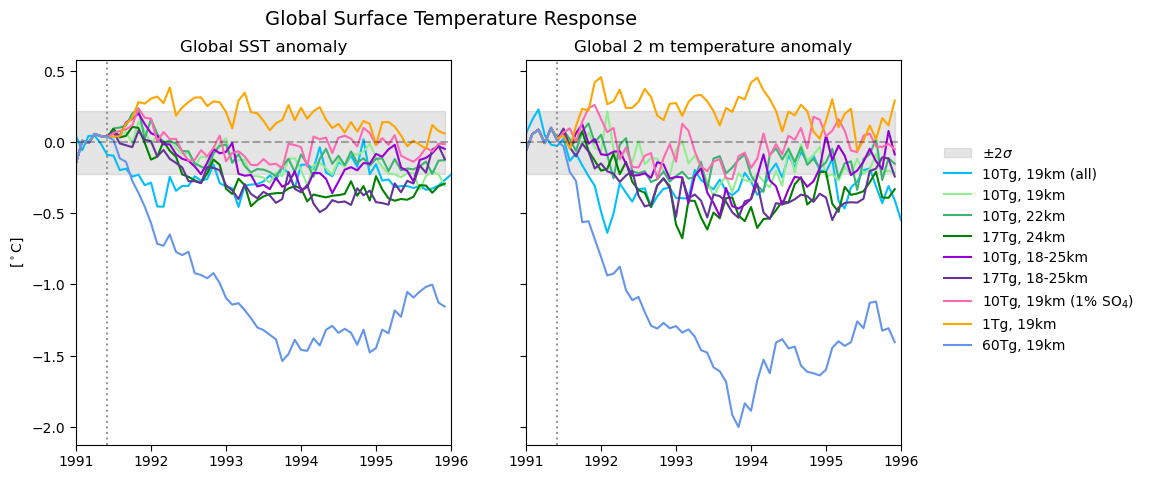

In [32]:
exp_order = [
    "10Tg, 19km (all)",
    "10Tg, 19km",
    "10Tg, 22km",
    "17Tg, 24km",
    "10Tg, 18-25km",
    "17Tg, 18-25km",
    "10Tg, 19km (1% SO$_4$)",
    "1Tg, 19km",
    "60Tg, 19km"
]

colors = {
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

ocn_fields = {
    "10Tg, 19km (all)": ocn_temp_19,
    "10Tg, 19km": ocn_temp_19_c,
    "10Tg, 22km": ocn_temp_22,
    "17Tg, 24km": ocn_temp_24,
    "10Tg, 18-25km": ocn_temp_1825,
    "17Tg, 18-25km": ocn_temp_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": ocn_temp_1pr,
    "1Tg, 19km": ocn_temp_1tg,
    "60Tg, 19km": ocn_temp_60tg
}

weights_dict = {
    "10Tg, 19km (all)": weighted_lat_19,
    "10Tg, 19km": weighted_lat_19_c,
    "10Tg, 22km": weighted_lat_22,
    "17Tg, 24km": weighted_lat_24,
    "10Tg, 18-25km": weighted_lat_1825,
    "17Tg, 18-25km": weighted_lat_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": weighted_lat_1pr,
    "1Tg, 19km": weighted_lat_1tg,
    "60Tg, 19km": weighted_lat_60tg
}

t2m_anom_dict = {
    "10Tg, 19km (all)": a_19,
    "10Tg, 19km": a_19_c,
    "10Tg, 22km": a_22,
    "17Tg, 24km": a_24,
    "10Tg, 18-25km": a_1825,
    "17Tg, 18-25km": a_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": a_1pr,
    "1Tg, 19km": a_1tg,
    "60Tg, 19km": a_60tg
}

sst_anom_dict = {}

for name in exp_order:
    ocn = ocn_fields[name]
    w = weights_dict[name]
    ocn_ts = ocn.weighted(w).mean(dim=["lat", "lon"])
    sst_anom_dict[name] = ocn_ts.groupby("time.month") - baseline_clim

base_ts = global_mean(baseline)
base_climatology = base_ts.groupby("time.month").mean()
base_anomalies = base_ts.groupby("time.month") - base_climatology

base_glob_std = base_anomalies.std()


fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey = True)

ref_sst = sst_anom_dict["10Tg, 19km"]
ref_t2m = t2m_anom_dict["10Tg, 19km"]

t_sst = to_float(ref_sst)
t_t2m = to_float(ref_t2m)

sst_band = np.full(len(ref_sst.time), 2 * baseline_sst_std.item())
t2m_band = np.full(len(ref_t2m.time), 2 * base_glob_std.item())

ax[0].fill_between(
    t_sst,
    -sst_band,
    sst_band,
    color="gray",
    alpha=0.2,
    zorder=0,
    label="$\\pm 2\\sigma$"
)

ax[1].fill_between(
    t_t2m,
    -t2m_band,
    t2m_band,
    color="gray",
    alpha=0.2,
    zorder=0,
    label="$\\pm 2\\sigma$"
)

for name in exp_order:
    c = colors[name]

    sst = sst_anom_dict[name]
    t2m = t2m_anom_dict[name]

    ax[0].plot(to_float(sst), sst, color=c, label=name)
    ax[1].plot(to_float(t2m), t2m, color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global SST anomaly", fontsize=12)
ax[1].set_title("Global 2 m temperature anomaly", fontsize=12)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.subplots_adjust(right=0.95)
fig.suptitle("Global Surface Temperature Response", fontsize=14)

plt.show()